In [1]:
# PROECT = EDA OF A SYNTHETIC DATASET

# DATASET = GAMING AND MENTAL HEALTH

# OBJECTIVE = RELATIONSHIP OF GAMING BEHAVIOURS AND MENTAL HEALTH

# KEY QUESTION:
# 1. WHAT IS THE RELATIONSHIP OF GAMING BEHAVIOURS TO A PERSON MENTAL HEALTH

In [2]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# IMPORTING DATASET
path = r"C:\Users\violy\OneDrive\Desktop\Data_Analyst\Project_Portfolio\Gaming_and_Mental_Hea;th\gaming_mental_health_10M_40features.csv"
raw_data = pd.read_csv(path, nrows = 200000)
df = raw_data.copy()
df

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,29,Male,37700,3.94,15,0,5.24,4.00,0.94,10,...,10,4.44,4.50,6.94,18.49,6.73,5.70,1.11,88,1
199996,44,Male,60179,2.77,32,8,9.23,1.25,0.17,4,...,0,3.81,7.60,7.12,31.79,7.63,5.98,4.92,67,6
199997,26,Female,122900,5.48,29,10,5.95,1.01,2.20,10,...,2,6.20,4.00,6.18,22.22,6.71,6.08,4.40,17,8
199998,14,Female,9594,9.60,19,20,5.87,9.25,0.41,7,...,6,7.45,1.76,3.11,23.24,14.40,7.40,3.69,89,9


In [4]:
# DATASET INFOMATION SUMMARY
def summary(df):
    print('===== DATASET SUMMARY INFORMATION =====')
    print('\nNumber of rows                     :\t', df.shape[0])
    print('\nNumber of columns                :\t', df.shape[1])
    print('\nNumber of duplicates              :\t', df.duplicated().sum())
    print('\nDataset infomation                  :')
    display(df.info())
    print('\nDataset description                 :')
    display(df.describe())

summary(df)

===== DATASET SUMMARY INFORMATION =====

Number of rows                     :	 200000

Number of columns                :	 39

Number of duplicates              :	 0

Dataset infomation                  :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         200000 non-null  int64  
 1   gender                      200000 non-null  object 
 2   income                      200000 non-null  int64  
 3   daily_gaming_hours          200000 non-null  float64
 4   weekly_sessions             200000 non-null  int64  
 5   years_gaming                200000 non-null  int64  
 6   sleep_hours                 200000 non-null  float64
 7   caffeine_intake             200000 non-null  float64
 8   exercise_hours              200000 non-null  float64
 9   stress_level                200000 non-nu

None


Dataset description                 :


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,35.984350,77449.687405,4.006938,19.986510,11.990070,6.998803,1.996431,1.999015,5.493630,5.001494,...,5.002705,4.996585,5.003915,5.990886,23.998414,8.012604,5.002930,4.015581,49.499815,5.501265
std,13.563101,41831.877722,2.837001,11.267647,7.209524,1.502767,1.993503,2.005823,2.875314,1.978857,...,3.160109,1.976166,1.983604,1.963129,3.998513,4.001561,1.979381,1.950018,28.858049,2.869866
min,13.000000,5000.000000,0.000000,1.000000,0.000000,0.270000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.450000,0.210000,0.000000,0.000000,0.000000,1.000000
25%,24.000000,41171.000000,1.920000,10.000000,6.000000,5.990000,0.570000,0.580000,3.000000,3.660000,...,2.000000,3.650000,3.650000,4.650000,21.300000,5.080000,3.650000,2.660000,24.000000,3.000000
50%,36.000000,77285.000000,3.360000,20.000000,12.000000,7.000000,1.380000,1.380000,5.000000,5.010000,...,5.000000,5.000000,5.000000,6.010000,24.000000,7.370000,5.000000,4.000000,50.000000,6.000000
75%,48.000000,113722.000000,5.400000,30.000000,18.000000,8.010000,2.770000,2.770000,8.000000,6.350000,...,8.000000,6.340000,6.360000,7.360000,26.680000,10.240000,6.350000,5.340000,74.000000,8.000000
max,59.000000,149999.000000,26.810000,39.000000,24.000000,13.990000,24.100000,26.480000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,43.600000,42.680000,10.000000,10.000000,99.000000,10.000000


In [5]:
# CHECKING DATA UNIQUENESS
def unique_summary(df):
    print('===== UNIQUE COLUMN VALUES SUMMARY =====')
    for col in df.columns:
        print(f'{col} :')
        print(df[col].unique())
        print('')

unique_summary(df)

===== UNIQUE COLUMN VALUES SUMMARY =====
age :
[51 41 27 55 20 33 31 35 23 36 48 52 15 34 14 56 42 50 45 24 37 39 54 40
 28 59 49 19 21 30 16 26 38 32 47 29 18 46 22 43 57 53 13 17 25 44 58]

gender :
['Female' 'Male' 'Other']

income :
[  8615  39453  40466 ...  59885  88476 132936]

daily_gaming_hours :
[ 3.68  5.7   1.58 ... 21.31 19.14 16.86]

weekly_sessions :
[22 34  8 39 17 37 31 15  1 38 33 13 32  5 26 36 24 27 20 29 16 21 18 12
 35  6  9 23  3 14 30  7 25 11 10 19  2 28  4]

years_gaming :
[17 16 22 24  0 19  3  2  4 15  8  6  5  9  1 13 23 11 14 12 18  7 20 21
 10]

sleep_hours :
[ 5.26  9.2   7.39 ... 12.78  1.57  1.68]

caffeine_intake :
[ 1.    0.7   2.24 ... 12.46 19.56 18.2 ]

exercise_hours :
[ 0.18  1.44  3.15 ... 14.17 20.31 12.49]

stress_level :
[ 3  8  1  2  4  6 10  9  5  7]

anxiety_score :
[4.06 6.76 9.57 ... 9.85 9.71 9.83]

depression_score :
[5.02 7.63 4.02 ... 9.98 9.18 0.11]

social_interaction_score :
[7.85 7.06 1.12 ... 0.49 0.48 0.03]

relationship_satis

In [6]:
# DATASET DOES NOT CONTAIN ANY MISSING OR INVALID DATA
# THEREFORE THE DATASET IS CLEAN

In [7]:
# BASIC MENTAL HEALTH CHECK
mental_health_cols = ['stress_level', 'anxiety_score', 'depression_score', 
                      'addiction_level', 'loneliness_score', 'aggression_score', 
                      'happiness_score']

print('===== MENTAL HEALTH SUMMARY STATS =====')
print(df[mental_health_cols].describe().round(2))

===== MENTAL HEALTH SUMMARY STATS =====
       stress_level  anxiety_score  depression_score  addiction_level  \
count     200000.00      200000.00         200000.00        200000.00   
mean           5.49           5.00              5.01             2.83   
std            2.88           1.98              2.40             2.11   
min            1.00           0.00              0.00             0.00   
25%            3.00           3.66              3.32             1.26   
50%            5.00           5.01              5.01             2.47   
75%            8.00           6.35              6.69             4.00   
max           10.00          10.00             10.00            10.00   

       loneliness_score  aggression_score  happiness_score  
count         200000.00         200000.00        200000.00  
mean               5.00              5.00             5.99  
std                1.98              1.98             1.96  
min                0.00              0.00             0.00

In [8]:
# BASIC GAMING BEHAVIOR CHECK
gaming_cols = ['daily_gaming_hours', 'night_gaming_ratio', 'violent_games_ratio', 
               'multiplayer_ratio', 'years_gaming', 'weekly_sessions']

print('===== GAMING BEHAVIOR SUMMARY STATS =====')
print(df[gaming_cols].describe().round(2))

===== GAMING BEHAVIOR SUMMARY STATS =====
       daily_gaming_hours  night_gaming_ratio  violent_games_ratio  \
count           200000.00           200000.00            200000.00   
mean                 4.01                0.50                 0.40   
std                  2.84                0.22                 0.20   
min                  0.00                0.00                 0.00   
25%                  1.92                0.33                 0.24   
50%                  3.36                0.50                 0.39   
75%                  5.40                0.67                 0.54   
max                 26.81                1.00                 0.99   

       multiplayer_ratio  years_gaming  weekly_sessions  
count          200000.00     200000.00        200000.00  
mean                0.50         11.99            19.99  
std                 0.22          7.21            11.27  
min                 0.00          0.00             1.00  
25%                 0.33          6.0

In [9]:
# CHECK FOR OUTLIERS
def outliers_check(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - (1.5 * IQR)
    higher = q3 + (1.5 * IQR)
    outliers = df[(df[column] < lower) | (df[column] > higher)]
    return len(outliers)

print('\n===== MENTAL HEALTH OUTLIERS =====')
for col in mental_health_cols:
    outliers = outliers_check(df, col)
    print(f"{col}: {outliers} outliers ({(outliers/len(df))*100:.2f}%)")

print('\n===== GAMING BEHAVIOUR OUTLIERS  =====')
for col in gaming_cols:
    outliers = outliers_check(df, col)
    print(f"{col}: {outliers} outliers ({(outliers/len(df))*100:.2f}%)")


===== MENTAL HEALTH OUTLIERS =====
stress_level: 0 outliers (0.00%)
anxiety_score: 0 outliers (0.00%)
depression_score: 0 outliers (0.00%)
addiction_level: 4937 outliers (2.47%)
loneliness_score: 0 outliers (0.00%)
aggression_score: 0 outliers (0.00%)
happiness_score: 676 outliers (0.34%)

===== GAMING BEHAVIOUR OUTLIERS  =====
daily_gaming_hours: 6271 outliers (3.14%)
night_gaming_ratio: 0 outliers (0.00%)
violent_games_ratio: 0 outliers (0.00%)
multiplayer_ratio: 0 outliers (0.00%)
years_gaming: 0 outliers (0.00%)
weekly_sessions: 0 outliers (0.00%)


In [10]:
# WE CAN CONCLUDE THAT ADDICTION LEVELS AND DAILY GAMING HOURS HAVE A LARGE AMOUNT OF OUTLIERS

===== GENDER DISTRIBUTION =====
gender
Male      96135
Female    95913
Other      7952
Name: count, dtype: int64



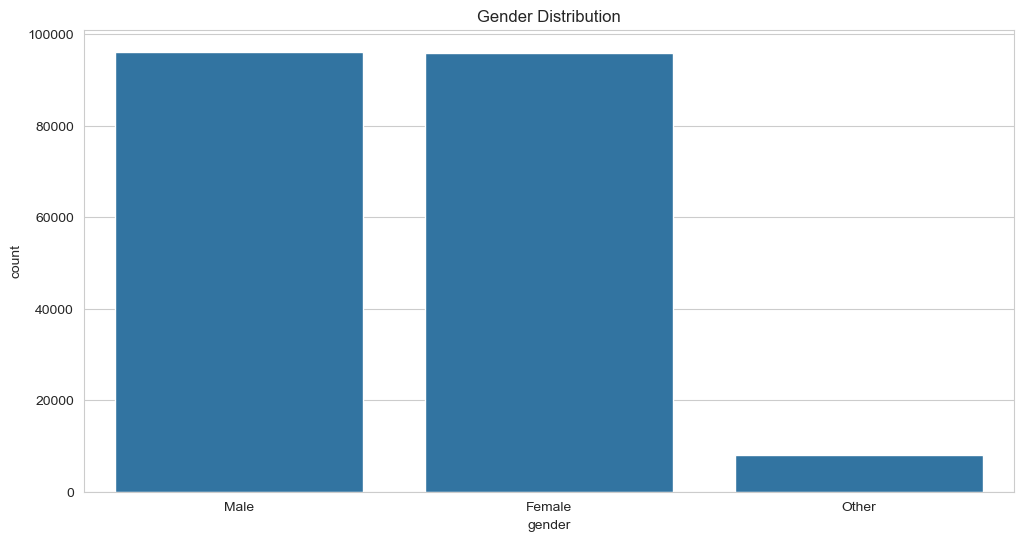

In [11]:
# GENDER DISTRIBUTION
gender_count = df['gender'].value_counts()
print('===== GENDER DISTRIBUTION =====')
print(gender_count)
print('')

sns.countplot(data=df, x="gender", order=df["gender"].value_counts().index)
plt.title("Gender Distribution")
plt.show()

===== MENTAL HEALTH BY GENDER =====
        stress_level  anxiety_score  depression_score  addiction_level  \
gender                                                                   
Female         5.500          4.994             5.006            2.828   
Male           5.490          5.006             5.008            2.833   
Other          5.464          5.043             5.013            2.870   

        loneliness_score  aggression_score  happiness_score  
gender                                                       
Female             4.988             5.006            5.985  
Male               5.003             4.997            5.996  
Other              5.021             5.066            6.001  



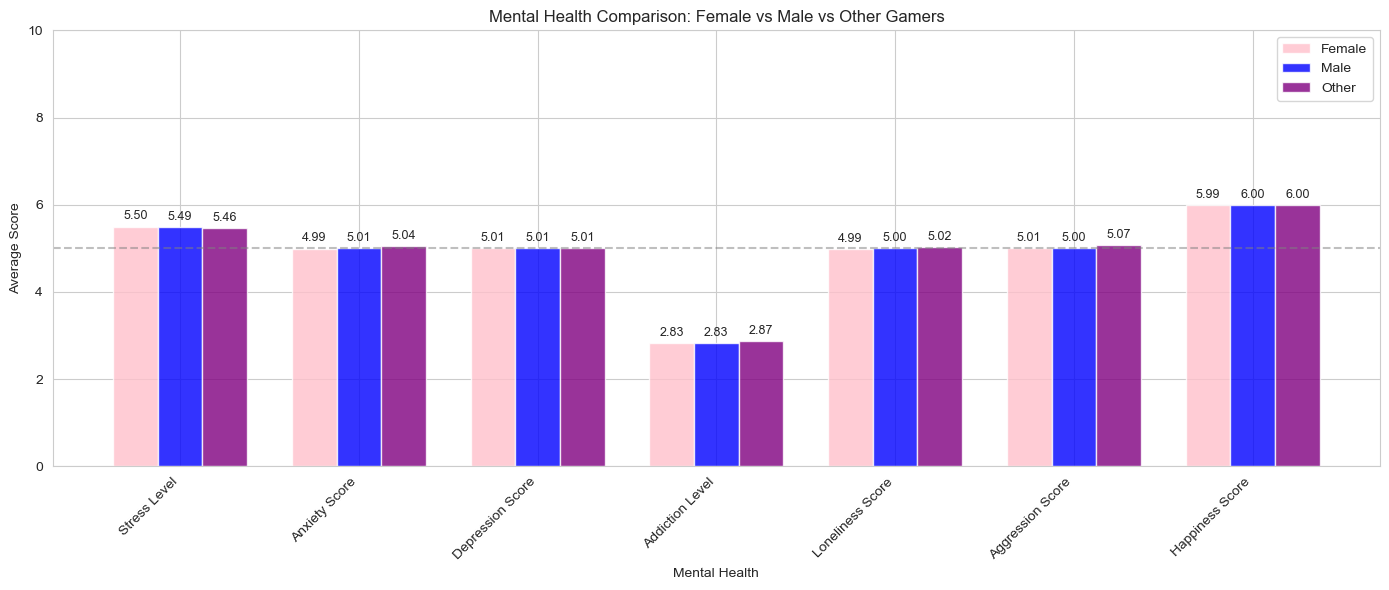

In [13]:
# WHAT IS THE DIFFERENCE IN MENTAL HEALTH BETWEEN DIFFERENT GENDERS
gender_ment = df.groupby('gender')[mental_health_cols].mean().round(3)
print('===== MENTAL HEALTH BY GENDER =====')
print(gender_ment)
print('')

# Visualization
female_scores = [gender_ment.loc['Female'][m] for m in mental_health_cols]
male_scores = [gender_ment.loc['Male'][m] for m in mental_health_cols]
other_scores = [gender_ment.loc['Other'][m] for m in mental_health_cols]

x = np.arange(len(mental_health_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, female_scores, width, label='Female', color='pink', alpha=0.8)
bars2 = ax.bar(x, male_scores, width, label='Male', color='blue', alpha=0.8)
bars3 = ax.bar(x + width, other_scores, width, label='Other', color='purple', alpha=0.8)

ax.set_xlabel('Mental Health')
ax.set_ylabel('Average Score')
ax.set_title('Mental Health Comparison: Female vs Male vs Other Gamers')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in mental_health_cols], rotation=45, ha='right')
ax.legend()
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Neutral (5)')
ax.set_ylim(0, 10)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show() 

In [14]:
# ANSWER:
# 1. THE GRAPH SHOWS THAT THE DATA IS CLOSELY RELATED BETWEEN EACH GENDER

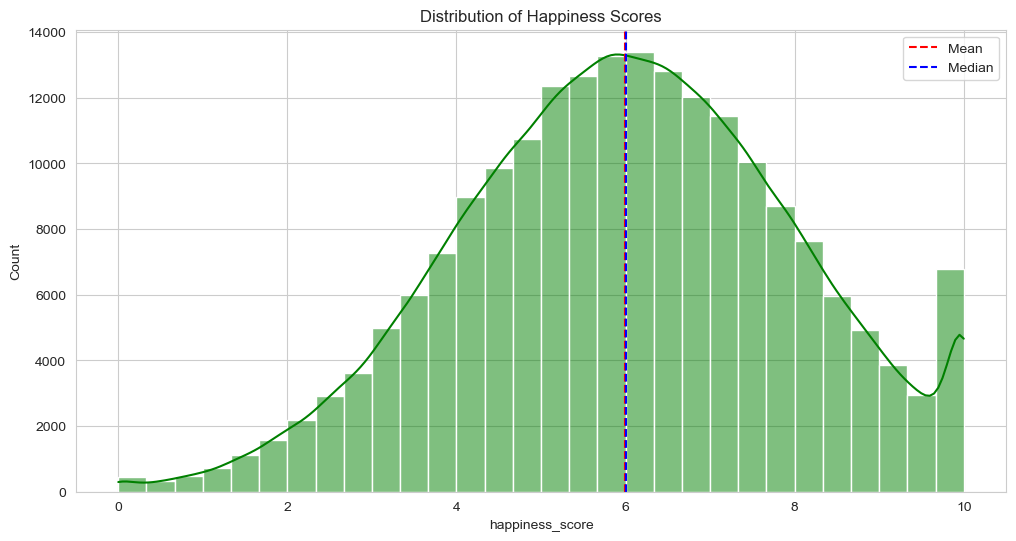

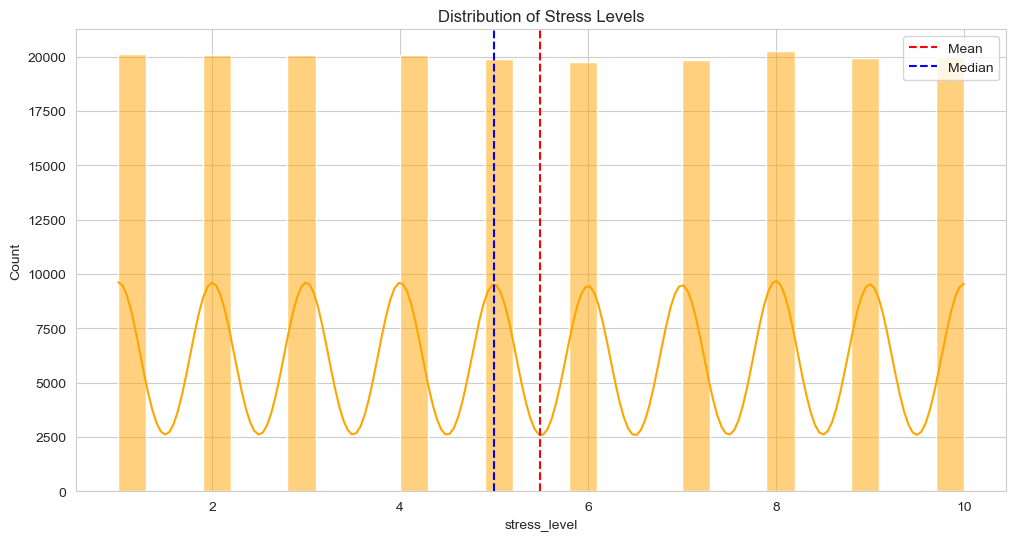

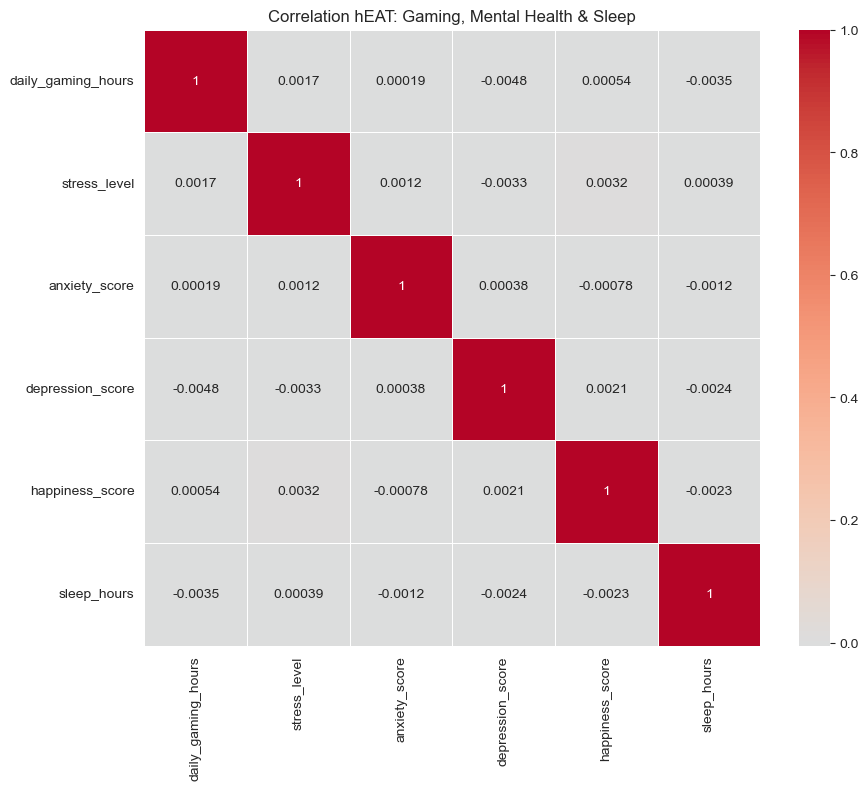

In [15]:
# DISTRIBUTION OF HAPPINESS SCORE
sns.histplot(df['happiness_score'], bins = 30, kde = True,  color = 'green')
plt.axvline(df['happiness_score'].mean(), color = 'red', linestyle = '--', label = 'Mean')
plt.axvline(df['happiness_score'].median(), color = 'blue', linestyle = '--', label = 'Median')
plt.title('Distribution of Happiness Scores')
plt.legend()
plt.show()

# DISTRIBUTION OF STRESS LEVELS
sns.histplot(df['stress_level'], bins = 30, kde = True, color = 'orange')
plt.axvline(df['stress_level'].mean(), color = 'red', linestyle = '--', label = 'Mean')
plt.axvline(df['stress_level'].median(), color = 'blue', linestyle = '--', label = 'Median')
plt.title('Distribution of Stress Levels')
plt.legend()
plt.show()

# CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
selected_cols = ['daily_gaming_hours', 'stress_level', 'anxiety_score', 'depression_score', 'happiness_score', 'sleep_hours']
sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm', center=0,  square=True, linewidths=0.5)
plt.title('Correlation Heatmap: Gaming, Mental Health & Sleep')
plt.show()

In [ ]:
# FROM THE GRAPHS ABOVE WE CAN CONCLUDE THAT:
# 1. THE DISTRIBUTION OF HAPPINESS IS NORMALLY DISTRIBUTED, WITH AN AVERAGE AROUND 6. MOST GAMERS FALL WITHIN THE 5-7 RANGE, SHOWING THAT THEY HAVE A POSITIVE WELL BEING
# 2. THE DISTRIBUTION OF STRESS LEVELS IS RIGHT SKEWED, WITH AN AVERAGE OF 5.5. THERE ARE 2 PEAKS WITHIN THE DATA, 1 IS THE RANGE  3-5 AND THE OTHER IS IN THE RANGE 7-9
# 3. THE HEATMAP SHOWS THAT THERE ARE NO LINEAR CORRELATION BETWEEN GAMING HOURS AND MENTAL HEALTH PROBLEMS

===== EXTREME VS NORMAL GAMERS =====
                     Extreme Gamers (Top 3%)  Normal Gamers
stress_level                            5.52           5.49
anxiety_score                           4.97           5.00
depression_score                        4.94           5.01
addiction_level                         8.72           2.65
loneliness_score                        5.01           5.00
aggression_score                        4.96           5.01
happiness_score                         5.99           5.99
daily_gaming_hours                     13.07           3.73
night_gaming_ratio                      0.50           0.50
violent_games_ratio                     0.40           0.40
multiplayer_ratio                       0.50           0.50
years_gaming                           11.88          11.99
weekly_sessions                        20.02          19.99



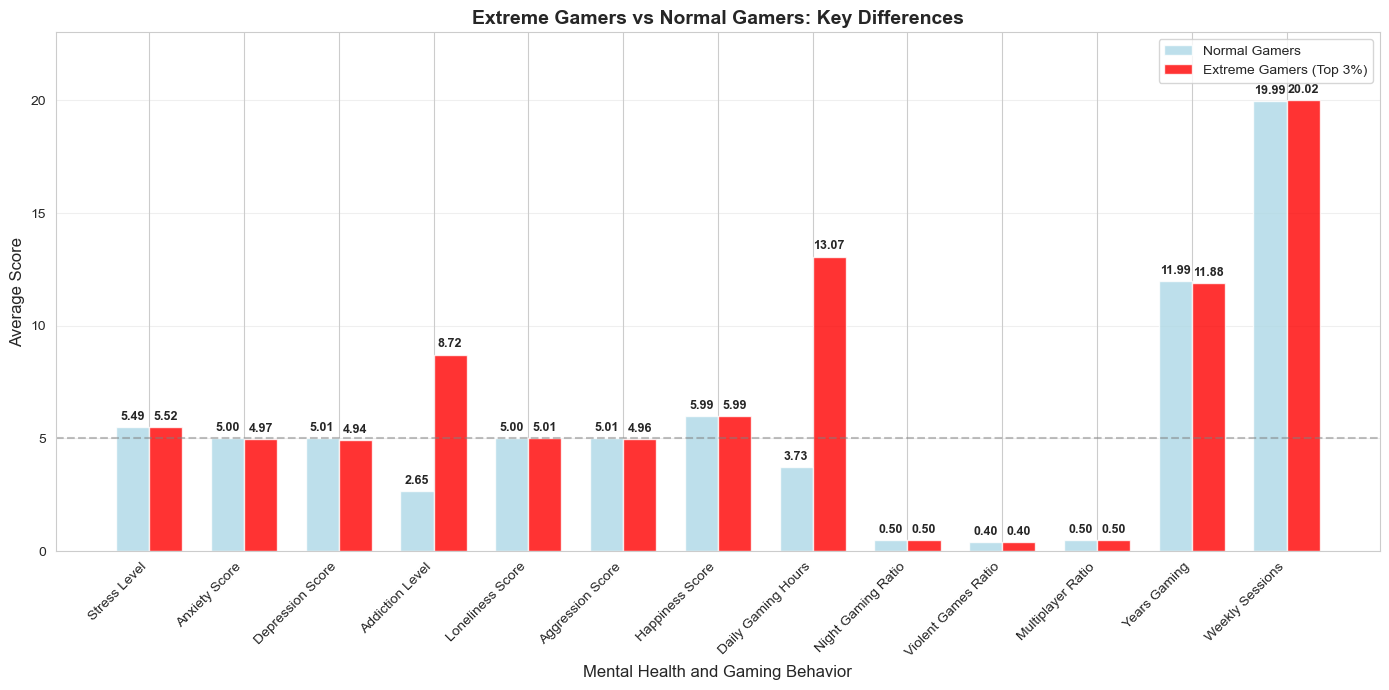

In [38]:
# DO EXTREME GAMERS HAVE DIFFERENT PATTERNS COMPARED TO NORMAL GAMERS?
extreme = df[df['daily_gaming_hours'] > df['daily_gaming_hours'].quantile(0.97)]
normal = df[df['daily_gaming_hours'] <= df['daily_gaming_hours'].quantile(0.97)]

comp_ext_norm = pd.DataFrame({
    'Extreme Gamers (Top 3%)': extreme[mental_health_cols + gaming_cols].mean(),
    'Normal Gamers': normal[mental_health_cols + gaming_cols].mean()}).round(2)

print('===== EXTREME VS NORMAL GAMERS =====')
print(comp_ext_norm)
print('')

# Visualize
extreme_values = [comp_ext_norm.loc[m, 'Extreme Gamers (Top 3%)'] for m in mental_health_cols + gaming_cols]
normal_values = [comp_ext_norm.loc[m, 'Normal Gamers'] for m in mental_health_cols + gaming_cols]

x = np.arange(len(mental_health_cols + gaming_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, normal_values, width, label='Normal Gamers', color='lightblue', alpha=0.8)
bars2 = ax.bar(x + width/2, extreme_values, width, label='Extreme Gamers (Top 3%)', color='red', alpha=0.8)

ax.set_xlabel('Mental Health and Gaming Behavior', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Extreme Gamers vs Normal Gamers: Key Differences', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in mental_health_cols + gaming_cols], rotation=45, ha='right')
ax.legend()
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Neutral (5)')
ax.set_ylim(0, max(extreme_values + normal_values) * 1.15)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),  xytext=(0, 3), textcoords="offset points",  ha='center', va='bottom',  fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# ANSWER:
# 1. EXTREME AND NORMAL GAMERS HAVE THE SIMILAR LEVELS TO EACH OTHER
# 2. EXTREME GAMERS HAVE A HIGHER LEVEL OF ADDICTION AND GAMING HOURS COMPARED TO NORMAL GAMERS
# 3. POSSIBLE REASON FOR HIGH STRESS AND HOURS, COULD BE DUE TO THEM BEING COMPETITIVE PLAYERS

In [25]:
# CHECKING IF EXTREME GAMERS AND HIGHLY ADDICTED PLAYERS ARE THE SAME?
# THE VALUES PROVIDED FOR ADDICTION LEVEL AND DAILY GAMING HOURS WAS USED DUE TO IT BEING THE OUTLIERS
high_addiction = df[df['addiction_level'] > 7] 
extreme_gamers = df[df['daily_gaming_hours'] > 10]

overlap = len(set(high_addiction.index) & set(extreme_gamers.index))

print('===== COUNT OF EXTREME AND HIGH ADDICTED GAMERS =====')
print(f"Extreme gamers: {len(extreme_gamers)}")
print(f"High addiction: {len(high_addiction)}")
print(f"Overlap: {overlap}")
print(f"% of extreme gamers with high addiction: {(overlap/len(extreme_gamers))*100:.1f}%")

===== COUNT OF EXTREME AND HIGH ADDICTED GAMERS =====
Extreme gamers: 8098
High addiction: 9565
Overlap: 6681
% of extreme gamers with high addiction: 82.5%


In [26]:
# ANSWER:
# 1. MAJORITY OF THE PLAYERS WITH HIGH DAILY GAMING HOURS ARE ADDICTED

In [28]:
# ARE THERE ANY DIFFERENCE BETWEEN EXTREME ADDICTED AND NON-ADDICTED GAMERS?
extreme_addicted = df[(df['daily_gaming_hours'] > 10) & (df['addiction_level'] > 7)]
extreme_nonaddicted = df[(df['daily_gaming_hours'] > 10) & (df['addiction_level'] <= 7)]

selected_cols = ['sleep_hours', 'social_interaction_score', 'relationship_satisfaction',
                'multiplayer_ratio', 'night_gaming_ratio', 'violent_games_ratio',
                'stress_level', 'happiness_score', 'anxiety_score']

difference = pd.DataFrame({'Extreme Addicted Gamers': extreme_addicted[selected_cols].mean(),
                                          'Extreme Non-Addicted Gamers': extreme_nonaddicted[selected_cols].mean(),
                                          'Difference': extreme_nonaddicted[selected_cols].mean() - extreme_addicted[selected_cols].mean()}).round(2)

print('===== EXTREME ADDICTED VS EXTREME NON ADDICTED =====')
print(difference)

===== EXTREME ADDICTED VS EXTREME NON ADDICTED =====
                           Extreme Addicted Gamers  \
sleep_hours                                   7.01   
social_interaction_score                      6.02   
relationship_satisfaction                     5.98   
multiplayer_ratio                             0.50   
night_gaming_ratio                            0.50   
violent_games_ratio                           0.40   
stress_level                                  5.54   
happiness_score                               6.00   
anxiety_score                                 4.99   

                           Extreme Non-Addicted Gamers  Difference  
sleep_hours                                       6.98       -0.04  
social_interaction_score                          6.01       -0.01  
relationship_satisfaction                         5.88       -0.10  
multiplayer_ratio                                 0.50        0.00  
night_gaming_ratio                                0.49       

In [29]:
# ANSWER:
# 1. NO, THE DATA BETWEEN ADDICTED AND NON ADDICTED GAMERS ARE VERY SIMILAR
# 2. WE CAN CONCLUDE THAT ADDICTION BETWEEN EXTREME GAMERS DOES NOT EFFECT THEIR MENTAL HEALTH

In [30]:
# ARE THERE ANY DIFFERENCE BETWEEN EXTREME ADDICTED AND NORMAL ADDICTED?
normal_addicted = df[(df['daily_gaming_hours'] <= 10) & (df['addiction_level'] > 7)]
difference_addicted = pd.DataFrame({'Extreme Addicted Gamers': extreme_addicted[selected_cols].mean(),
                                          'Normal Addicted Gamers': normal_addicted[selected_cols].mean(),
                                          'Difference': normal_addicted[selected_cols].mean() - extreme_addicted[selected_cols].mean()}).round(2)
print('===== EXTREME ADDICTED VS NORMAL ADDDICTED')
print(difference_addicted)

===== EXTREME ADDICTED VS NORMAL ADDDICTED
                           Extreme Addicted Gamers  Normal Addicted Gamers  \
sleep_hours                                   7.01                    7.00   
social_interaction_score                      6.02                    6.01   
relationship_satisfaction                     5.98                    5.97   
multiplayer_ratio                             0.50                    0.49   
night_gaming_ratio                            0.50                    0.50   
violent_games_ratio                           0.40                    0.39   
stress_level                                  5.54                    5.48   
happiness_score                               6.00                    5.96   
anxiety_score                                 4.99                    5.03   

                           Difference  
sleep_hours                     -0.02  
social_interaction_score        -0.00  
relationship_satisfaction       -0.02  
multiplayer_rati

In [31]:
# ANSWER:
# 1. NO, THE DIFFERENCE IS VERY SUBTLE
# 2. ALL GAMERS THAT ARE ADDICTED HAVE THE SIMILAR MENTAL HEALTH

In [33]:
healthy_normal = df[(df['daily_gaming_hours'] <= 10) & (df['addiction_level'] <= 7)]

compare = pd.DataFrame({
    'Addicted Normal': normal_addicted[['stress_level', 'happiness_score', 
                                         'sleep_hours', 'social_interaction_score']].mean(),
    'Healthy Normal': healthy_normal[['stress_level', 'happiness_score',
                                       'sleep_hours', 'social_interaction_score']].mean(),
    'Difference': normal_addicted[['stress_level', 'happiness_score',
                                    'sleep_hours', 'social_interaction_score']].mean() - 
                  healthy_normal[['stress_level', 'happiness_score',
                                   'sleep_hours', 'social_interaction_score']].mean()
}).round(3)

print('===== ADDICTED VS NORMAL GAMERS =====')
print(compare)

===== ADDICTED VS NORMAL GAMERS =====
                          Addicted Normal  Healthy Normal  Difference
stress_level                        5.483           5.493      -0.010
happiness_score                     5.955           5.991      -0.035
sleep_hours                         6.997           6.999      -0.002
social_interaction_score            6.015           5.979       0.036


In [34]:
# ANSWER;
# 1. WE CAN CONCLUDE THAT EVEN  THOUGH ADDICTION LEVELS HAD A LARGE AMOUNT OF OUTLIERS, THERES NO REAL DIFFERENCE IN THEIR MENTAL HEALTH

In [35]:
# COUNT OF DIFFERENT TYPE OF GAMERS
multiplayer = df[df['multiplayer_ratio'] > df['multiplayer_ratio'].quantile(0.75)]
violent = df[df['violent_games_ratio'] > df['violent_games_ratio'].quantile(0.75)]
mobile = df[df['mobile_gaming_ratio'] > df['mobile_gaming_ratio'].quantile(0.75)]
balanced = df[(df['multiplayer_ratio'].between(0.25, 0.75)) & 
              (df['violent_games_ratio'].between(0.25, 0.75)) & 
              (df['mobile_gaming_ratio'].between(0.25, 0.75))]

print('===== COUNT OF DIFFERENT TYPE OF GAMERS =====')
print(f"Multiplayer-focused: {len(multiplayer)} gamers")
print(f"Violence-focused: {len(violent)} gamers")
print(f"Mobile-focused: {len(mobile)} gamers")
print(f"Balanced gamers: {len(balanced)} gamers")

===== COUNT OF DIFFERENT TYPE OF GAMERS =====
Multiplayer-focused: 49773 gamers
Violence-focused: 49438 gamers
Mobile-focused: 49656 gamers
Balanced gamers: 67944 gamers


In [20]:
# DOES DIFFERENT GAMING STYLES EFFECT MENTAL HEALTH?
style_comparison = pd.DataFrame({
    'Multiplayer-Focused': multiplayer[mental_health_cols].mean(),
    'Violence-Focused': violent[mental_health_cols].mean(),
    'Mobile-Focused': mobile[mental_health_cols].mean(),
    'Balanced Gamers': balanced[mental_health_cols].mean()
}).round(3)

print('===== MENTAL HEALTH BY GAMING STYLE =====')
print(style_comparison)

===== MENTAL HEALTH BY GAMING STYLE =====
                  Multiplayer-Focused  Violence-Focused  Mobile-Focused  \
stress_level                    5.494             5.481           5.499   
anxiety_score                   5.002             5.000           5.004   
depression_score                4.999             5.004           5.001   
addiction_level                 2.850             2.833           2.827   
loneliness_score                5.006             5.001           4.990   
aggression_score                5.010             4.999           5.006   
happiness_score                 5.999             6.003           5.984   

                  Balanced Gamers  
stress_level                5.494  
anxiety_score               4.999  
depression_score            4.995  
addiction_level             2.822  
loneliness_score            4.995  
aggression_score            4.997  
happiness_score             5.995  


In [ ]:
# FINAL THOUGHTS AND CONCLUSION
# 1. THIS SYNTHETIC DATA SET SHOWED NO RELATIONSHIP BETWEEN GAMING BEHAVIOURS AND MENTAL HEALTH ISSUES
# 2. THE REASON FOR THIS EDA WAS TO ANALYSIS THE SYNTHETIC DATASET AND NOT TO DETERMINE REAL WORLD QUESTIONS